## Understanding the problem

In [1]:
import pandas as pd

data=pd.read_csv("diabetes.csv")
data.info()

data.dtypes

data.columns

data.index

data.sample()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
182,1,0,74,20,23,27.7,0.299,21,0


In [2]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


# Analyser et explorer les données (EDA) 

### Analyse univarié

#### la fonction subplot

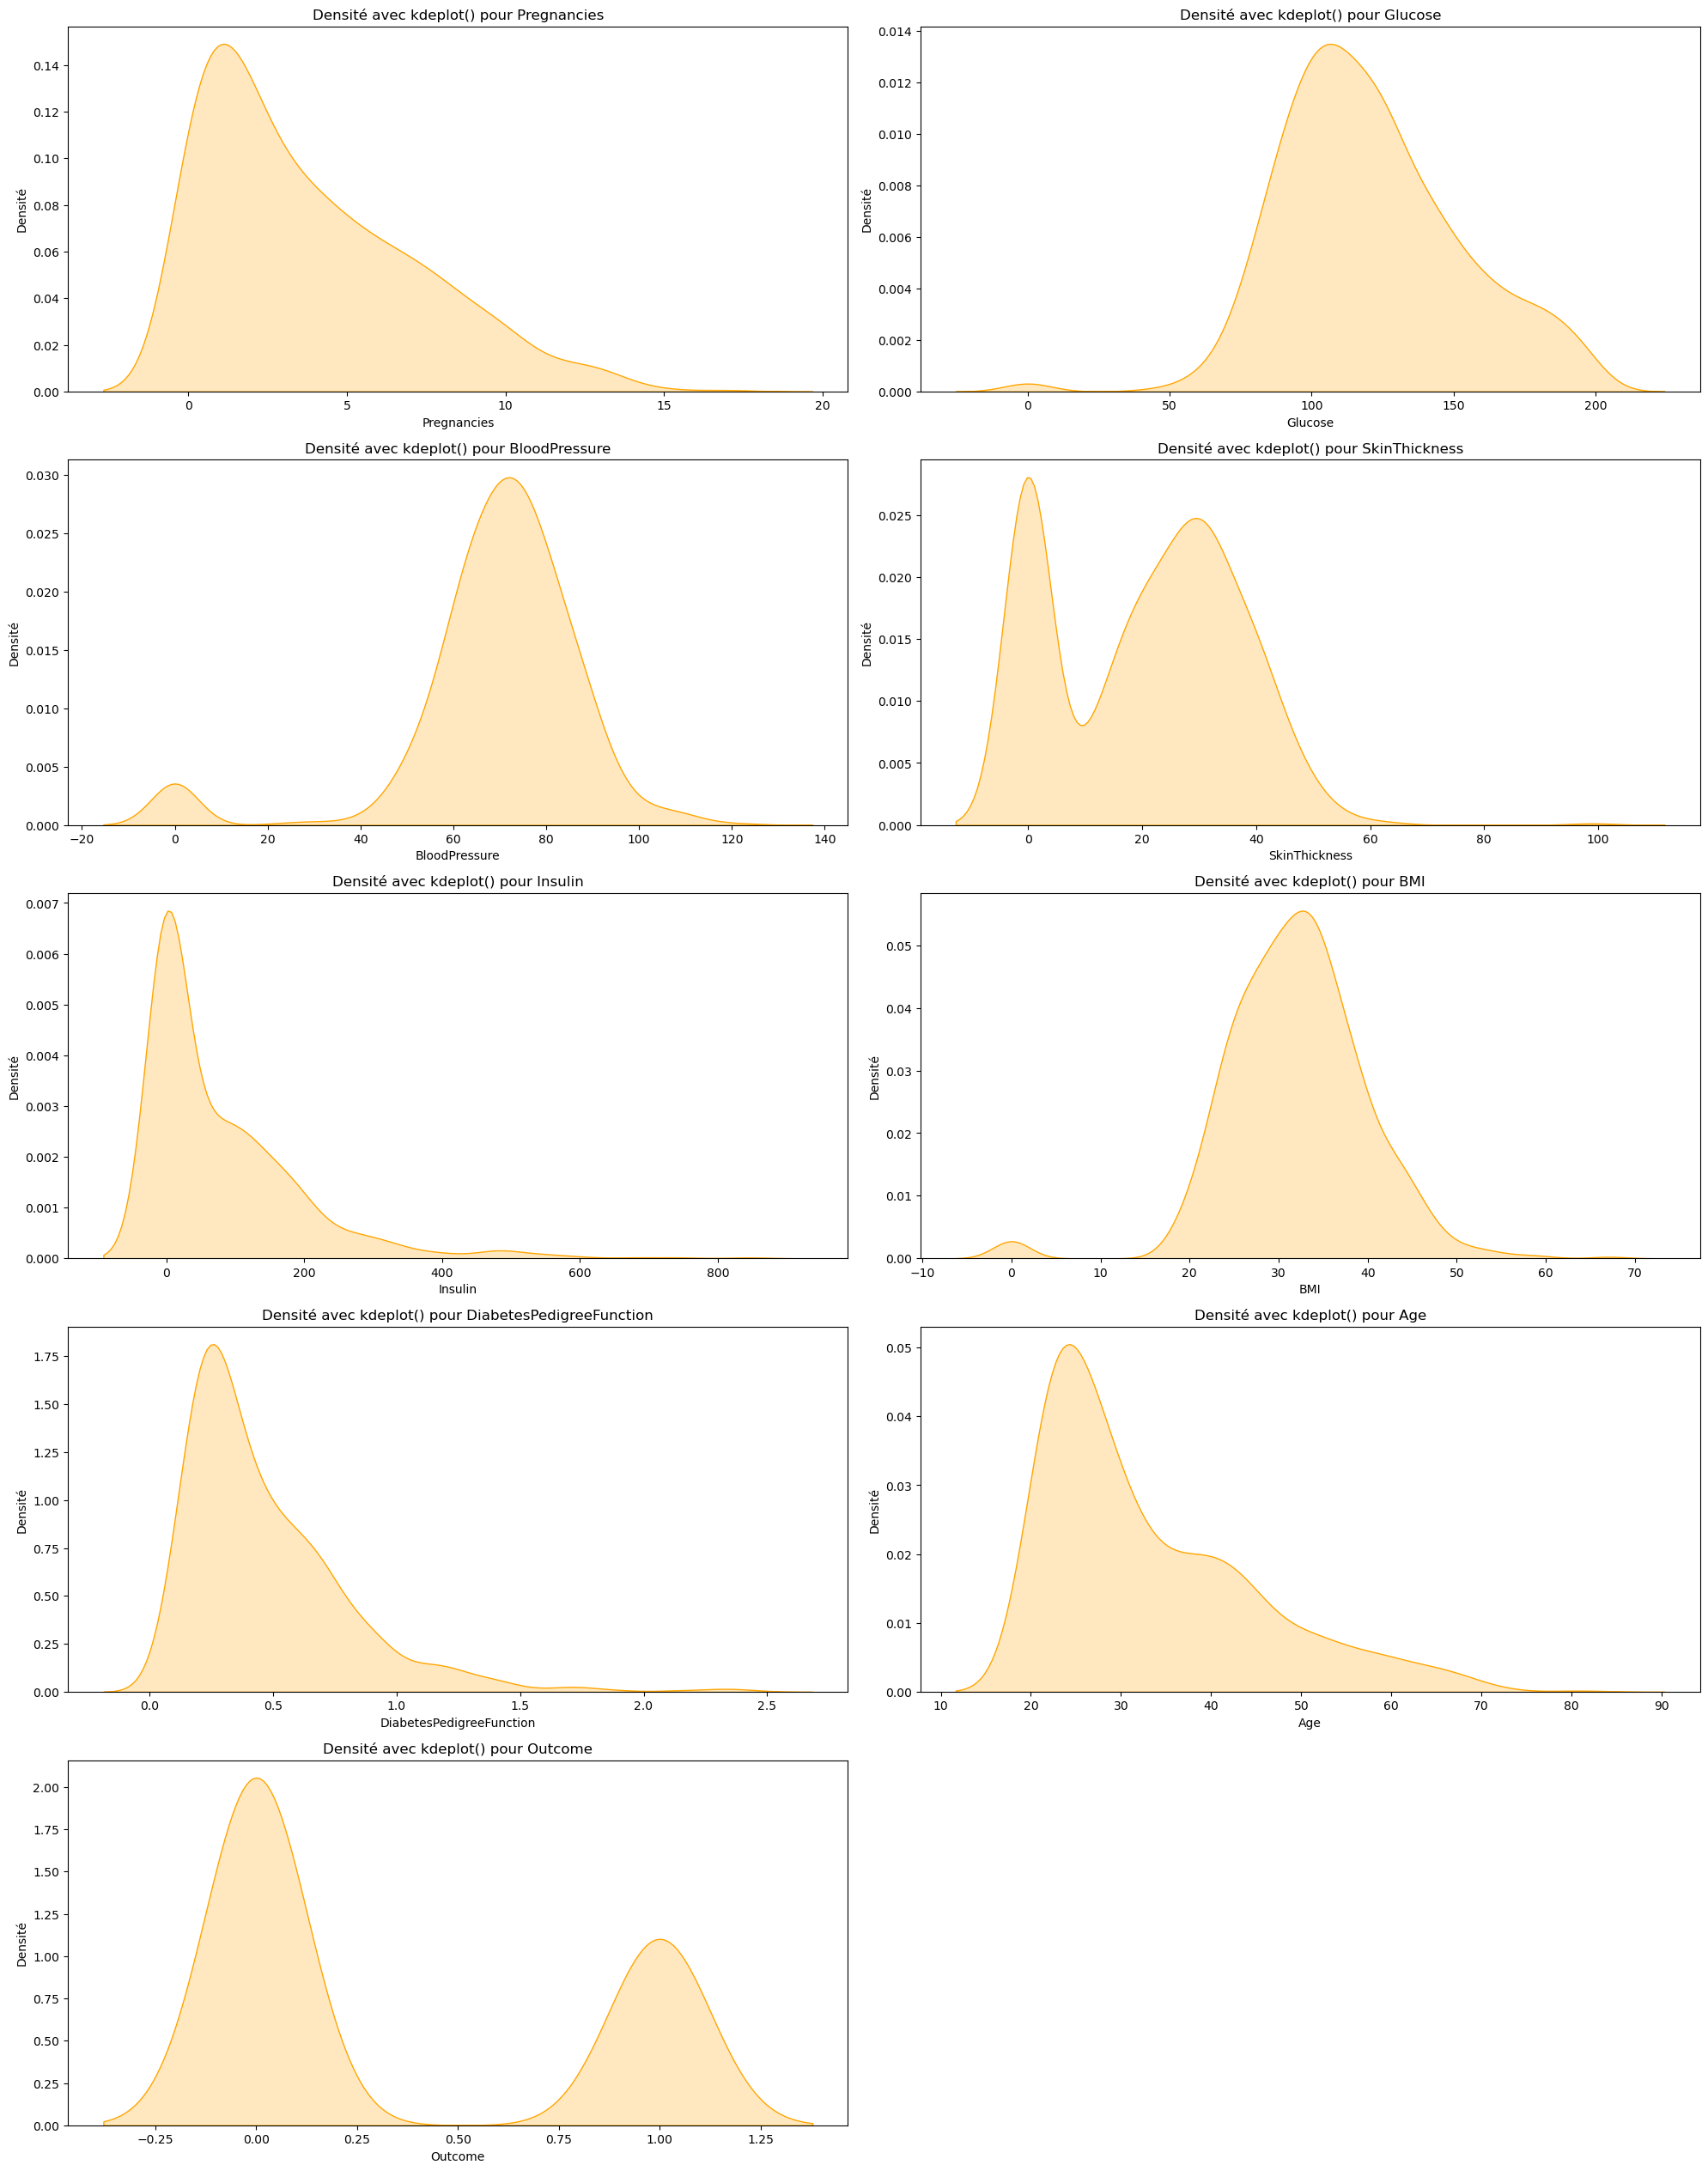

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
data = pd.read_csv("diabetes.csv")
# Define numeric_cols
numeric_cols = data.select_dtypes(include=['number']).columns.tolist()

plt.figure(figsize=(20, 30))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(6, 2, i)
    sns.kdeplot(data=data, x=col, fill=True, color='orange')
    plt.title(f'Densité avec kdeplot() pour {col}')
    plt.xlabel(col)
    plt.ylabel("Densité")

plt.tight_layout()
plt.show()

### La fonction countplot

C:\Users\intel\AppData\Local\Temp\ipykernel_10088\427572528.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y="Outcome", data=data, palette="pastel")


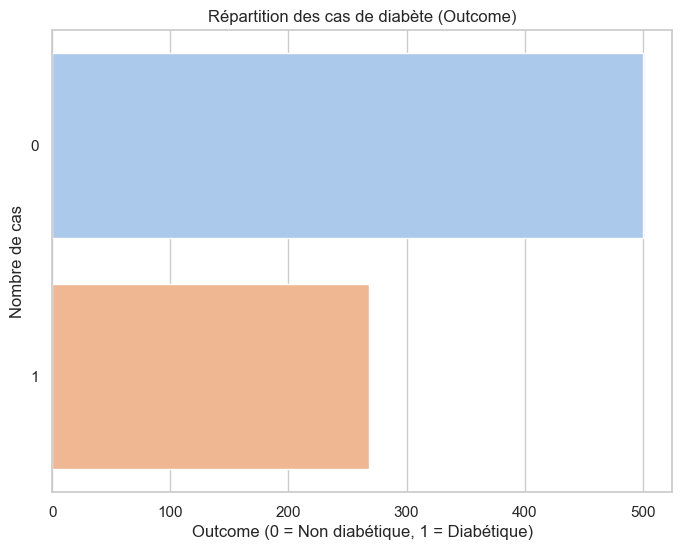

In [5]:
plt.figure(figsize=(8, 6))

sns.countplot(y="Outcome", data=data, palette="pastel")

plt.title('Répartition des cas de diabète (Outcome)')
plt.xlabel('Outcome (0 = Non diabétique, 1 = Diabétique)')
plt.ylabel('Nombre de cas')
plt.show()


### La fonction barplot

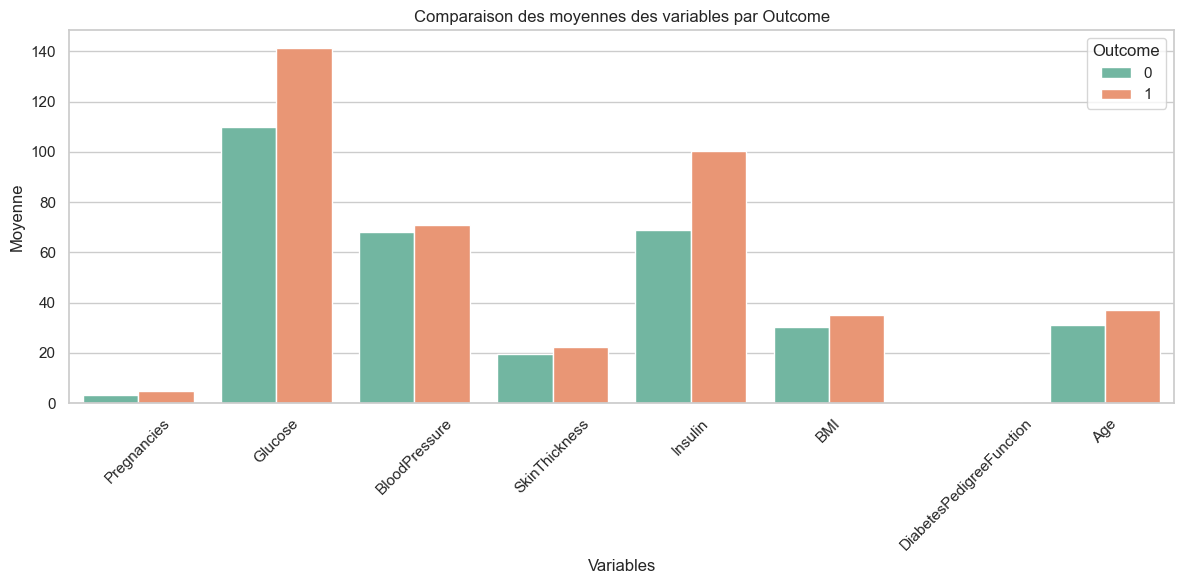

In [ ]:
# Average of variables grouped by Outcome
mean_values = data.groupby('Outcome').mean(numeric_only=True).reset_index().melt(id_vars='Outcome')

# Barplot
plt.figure(figsize=(12, 6))
sns.barplot(data=mean_values, x='variable', y='value', hue='Outcome', palette='Set2')
plt.title('Comparaison des moyennes des variables par Outcome')
plt.xticks(rotation=45)
plt.ylabel('Moyenne')
plt.xlabel('Variables')
plt.legend(title='Outcome')
plt.tight_layout()
plt.show()


# Analyse bivarié

### La fonction jointplot

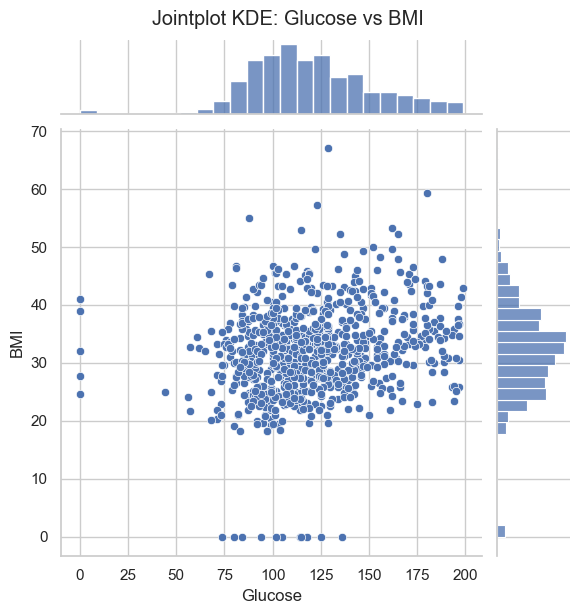

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.jointplot(x='Glucose', y='BMI', data=data)
plt.suptitle("Jointplot KDE: Glucose vs BMI", y=1.02)
plt.show()


### la fonction regplot

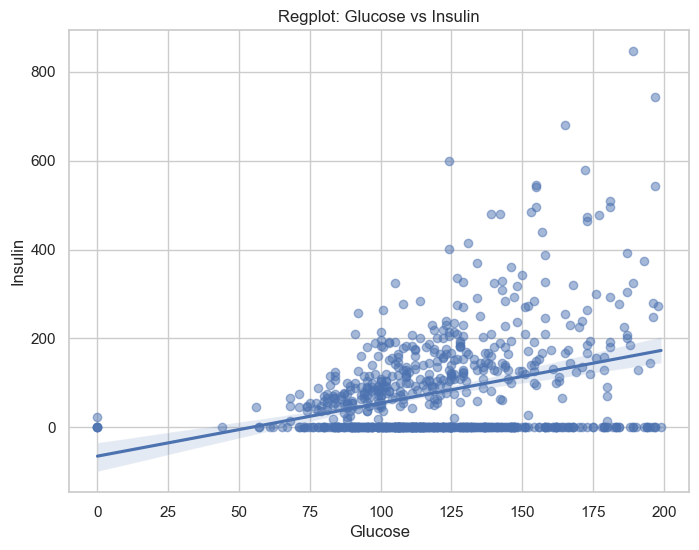

In [8]:
plt.figure(figsize=(8, 6))
sns.regplot(data=data, x='Glucose', y='Insulin', scatter_kws={'alpha': 0.5})
plt.title("Regplot: Glucose vs Insulin")
plt.xlabel("Glucose")
plt.ylabel("Insulin")
plt.show()

### La fonction lmplot

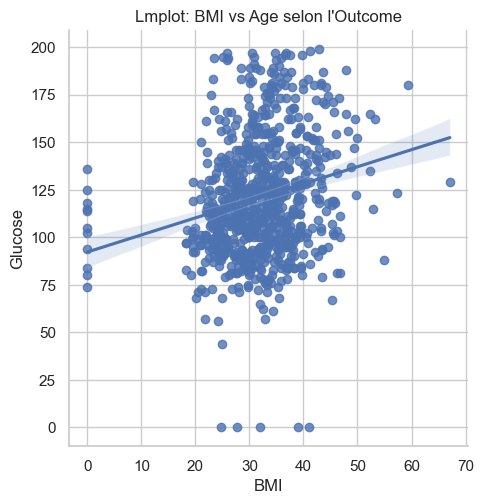

In [9]:
sns.lmplot(data=data, x='BMI', y='Glucose', palette="Set1")
plt.title("Lmplot: BMI vs Age selon l'Outcome")
plt.show()

### La fonction pairplot

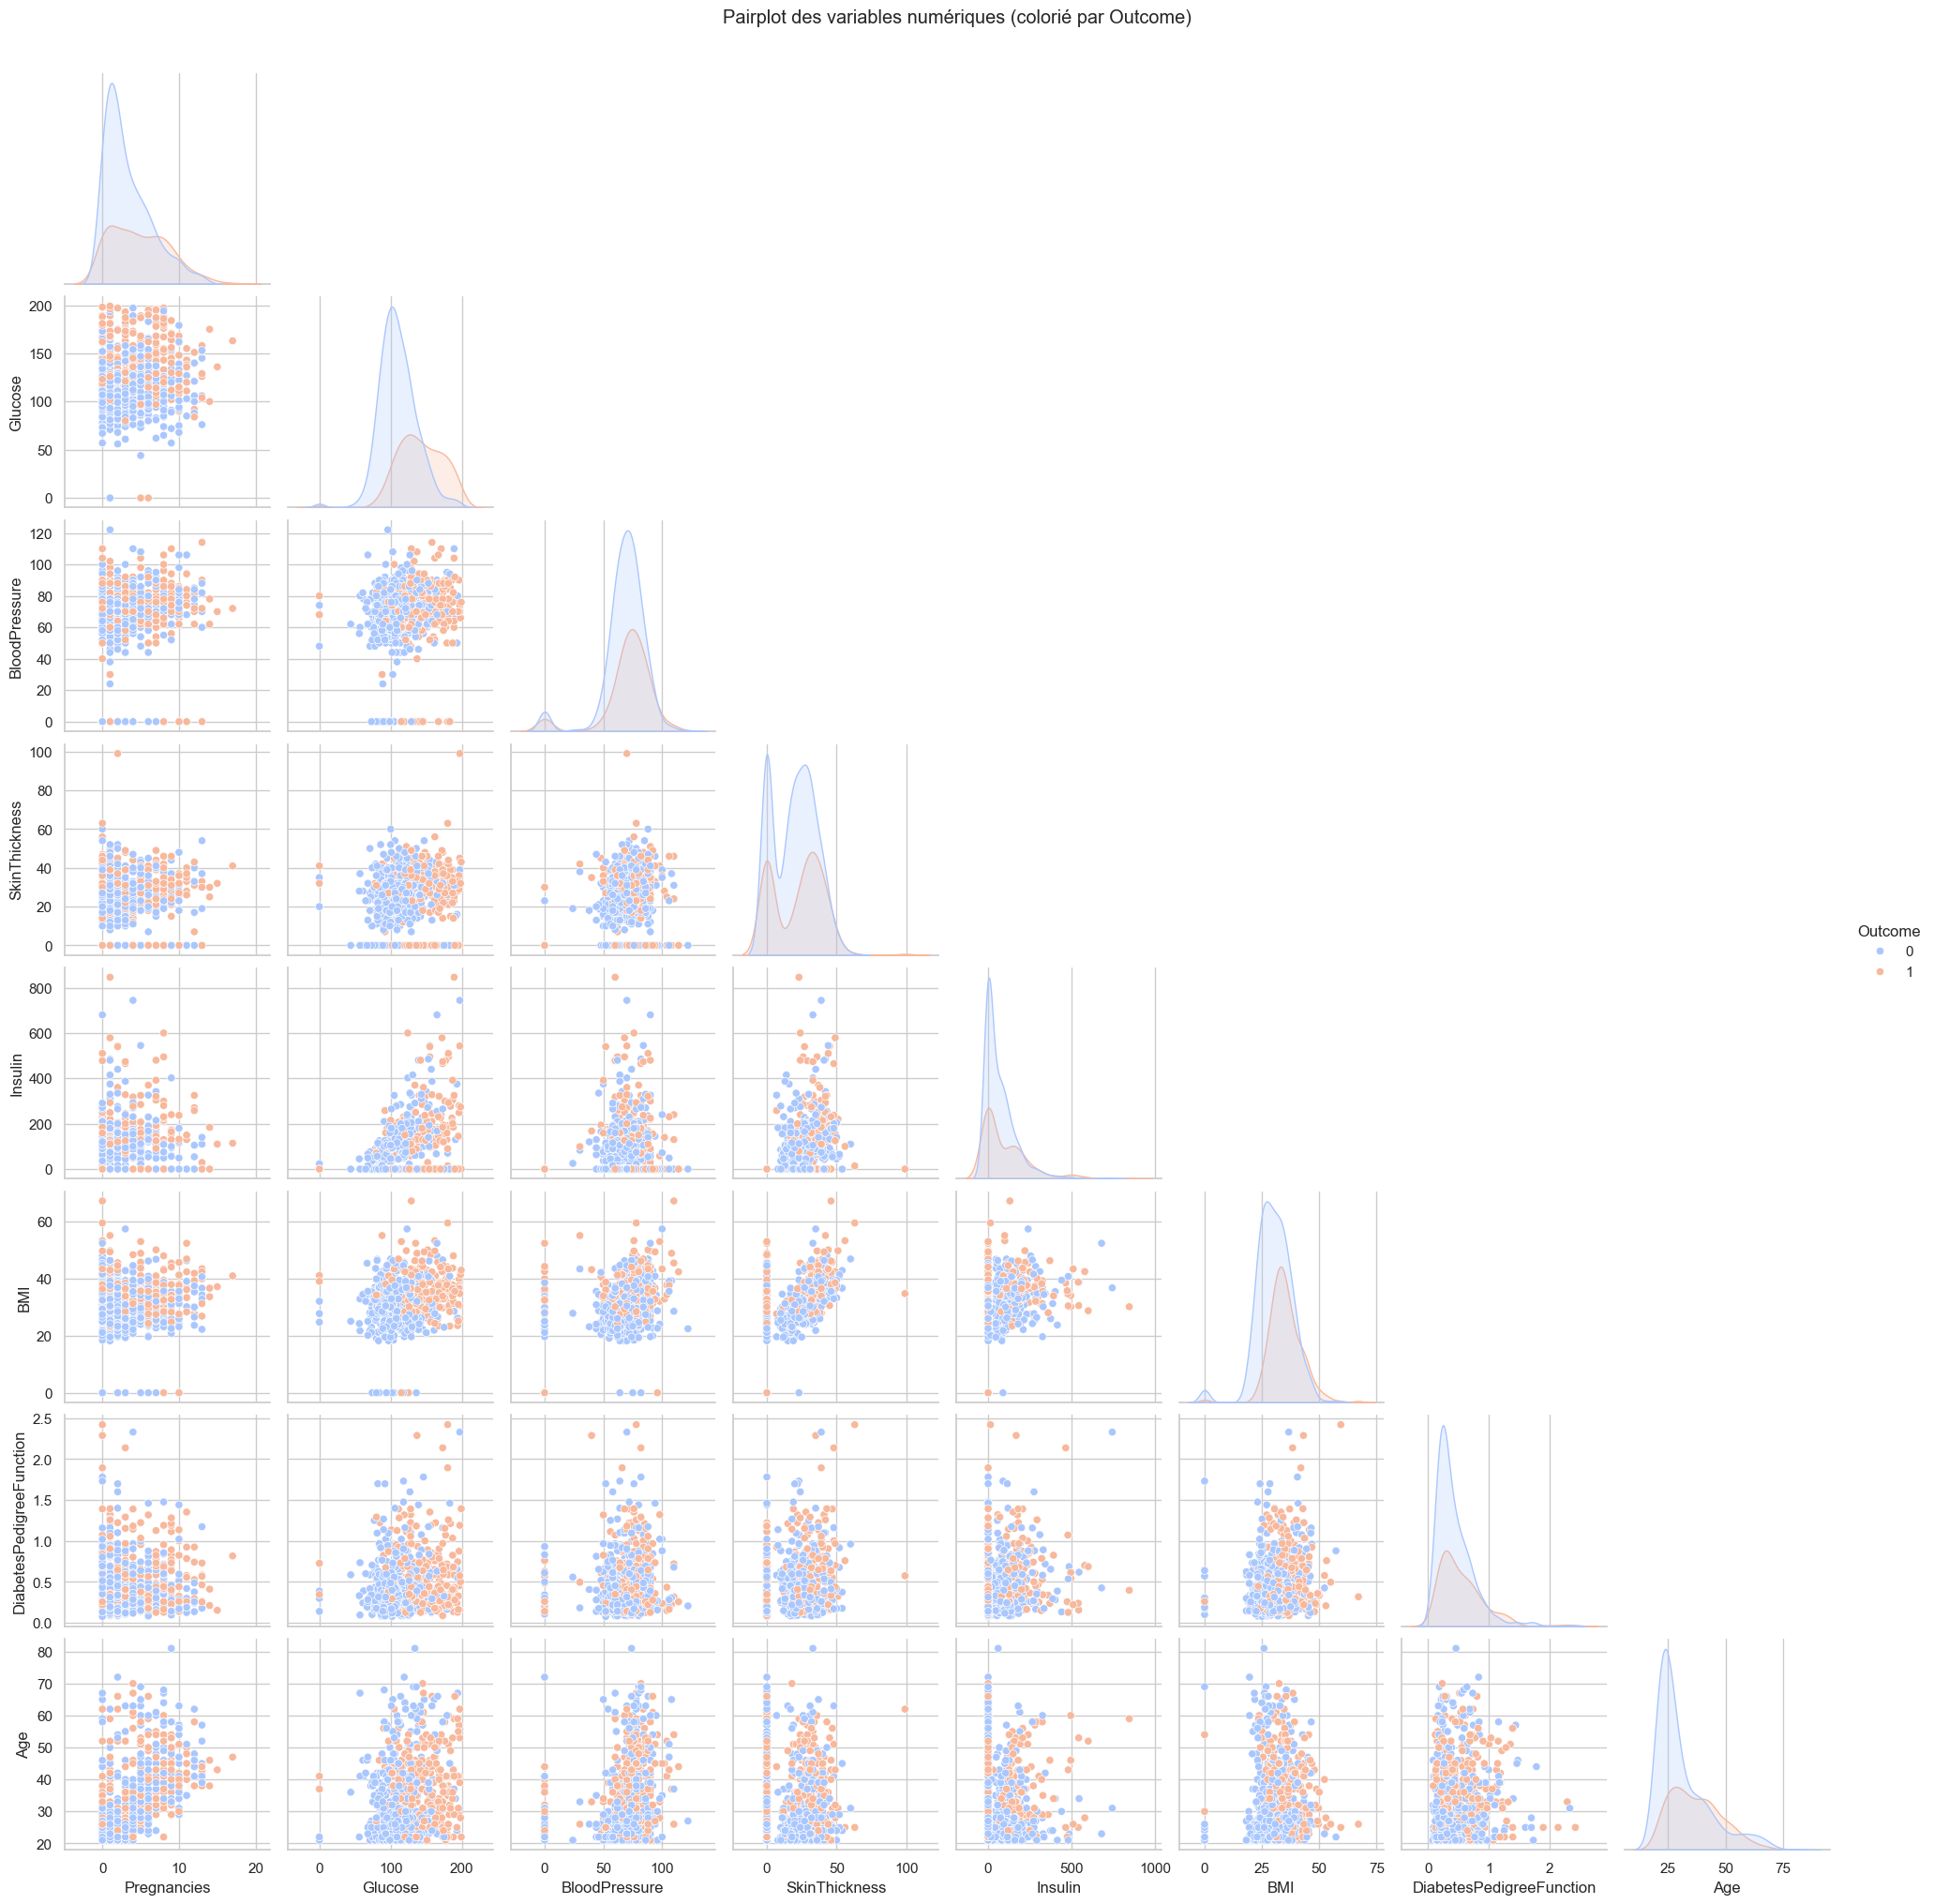

In [ ]:
sns.pairplot(data, hue='Outcome', corner=True, palette='coolwarm')
plt.suptitle("Pairplot des variables numériques (colorié par Outcome)", y=1.02)
plt.show()

## Analyse multivarié

### La fonction FacetGrid

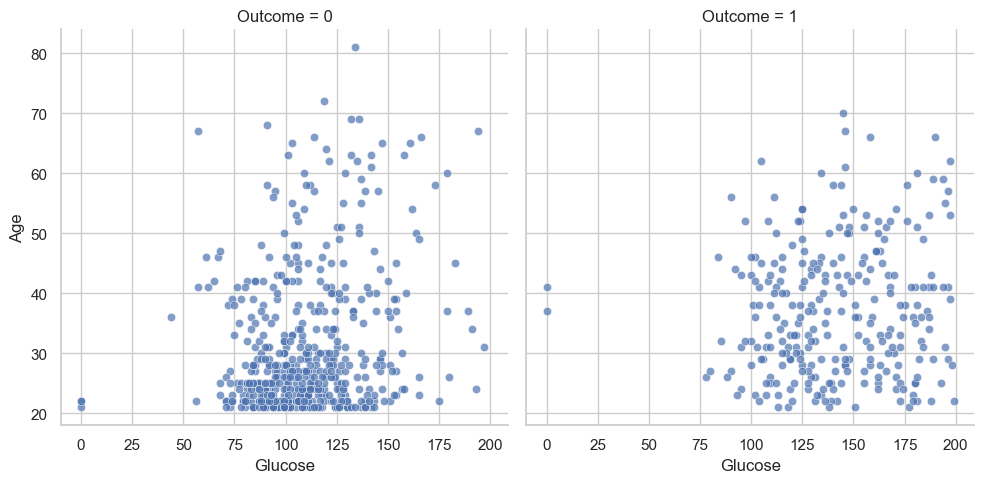

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



# Créer la grille de facettes selon Outcome
g = sns.FacetGrid(data, col="Outcome", height=5)
g.map_dataframe(sns.scatterplot, x="Glucose", y="Age", alpha=0.7)

g.set_axis_labels("Glucose", "Age")
g.set_titles("Outcome = {col_name}")

plt.show()


# Feature engineering

In [12]:
print(data.dtypes)

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object


#### We have all the variables are of numeric type, in we do not need to encode categorical variables

### handling missing values

In [13]:
data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

#### replacing 0s with null values

In [14]:
# Replace 0 values ​​in some columns with NaN to handle missing values
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
data[cols_with_zeros] = data[cols_with_zeros].replace(0, np.nan)

### missing value detection

In [15]:
data.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

## Creation of new variables: imputation of missing values

In [16]:

data["Glucose"].fillna(data["Glucose"].mean(), inplace = True)
data["BloodPressure"].fillna(data["BloodPressure"].mean(), inplace = True)
data["SkinThickness"].fillna(data["SkinThickness"].median(), inplace = True)
data["Insulin"].fillna(data["Insulin"].mean(), inplace = True)
data["BMI"].fillna(data["BMI"].mean(), inplace = True)

C:\Users\intel\AppData\Local\Temp\ipykernel_10088\810028390.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data["Glucose"].fillna(data["Glucose"].mean(), inplace = True)
C:\Users\intel\AppData\Local\Temp\ipykernel_10088\810028390.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a co

### no null value

In [17]:
#at this part we're gonna find 0 null value bcause we filled them with the mean and median based on the data distribution
data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [18]:
# in another time we show the data discription after we cleaning it and filling the null values 
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.000000,6.000000,17.00
Glucose,768.0,121.686763,30.435949,44.000,99.75000,117.000000,140.250000,199.00
BloodPressure,768.0,72.405184,12.096346,24.000,64.00000,72.202592,80.000000,122.00
SkinThickness,768.0,29.108073,8.791221,7.000,25.00000,29.000000,32.000000,99.00
Insulin,768.0,155.548223,85.021108,14.000,121.50000,155.548223,155.548223,846.00
BMI,768.0,32.457464,6.875151,18.200,27.50000,32.400000,36.600000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.372500,0.626250,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.000000,41.000000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.000000,1.000000,1.00


## Transformation of variables (standardization, normalization)

##### to make the machine learning models understand the data , we can transform the variables using the transformation algorithmes like normalisation or standarization 

In [19]:
#MinMaxScaler
from sklearn.preprocessing import MinMaxScaler

normalizer = MinMaxScaler()
normalized_features = normalizer.fit_transform(data[['SkinThickness', 'Insulin']])

In [20]:
#standarisation Z-Score
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(data[['Pregnancies', 'Glucose', 'BloodPressure', 'BMI', 'Age']])


# Machine learning

##### In this part we're preparing the data for machine learning by selecting the relevant input features and target variable then splitting the data into training and testing sets. The training set is used to teach the model, while the test set is kept aside to evaluate how well the model performs on unseen data, ensuring it can generalize and not just memorize the training data.

In [21]:

from sklearn.model_selection import train_test_split
X = data.iloc[:, [1, 4, 5, 7]].values
Y = data.iloc[:, 8].values

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [22]:
# dimension check
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Y_train shape:", Y_train.shape)
print("Y_test shape:", Y_test.shape)

X_train shape: (614, 4)
X_test shape: (154, 4)
Y_train shape: (614,)
Y_test shape: (154,)


# Regression Logistique

#### In this part, we're gonna train the logistic regression model to predict diabetes. We'll then evaluate its performance using metrics like accuracy, a confusion matrix, and the ROC curve. To make the model interpretable, we will also visualize the influence and importance of each feature.

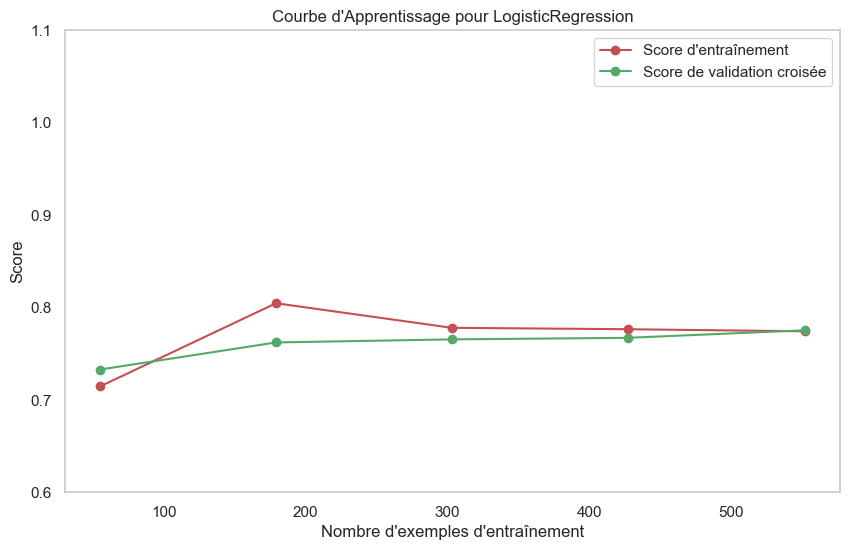

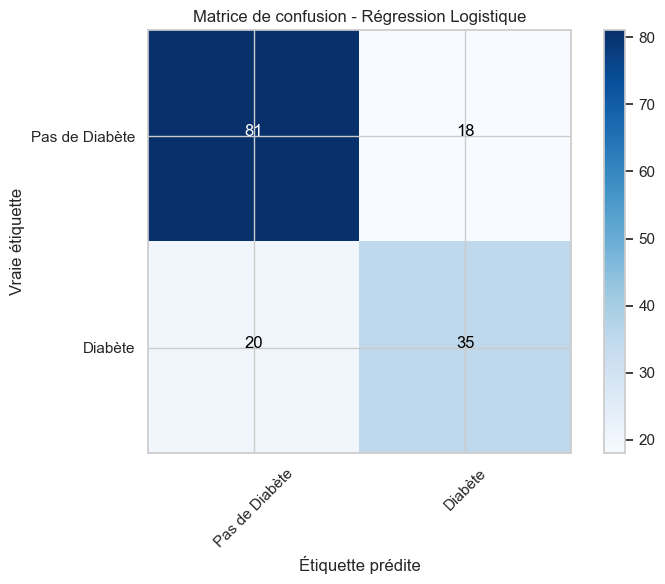

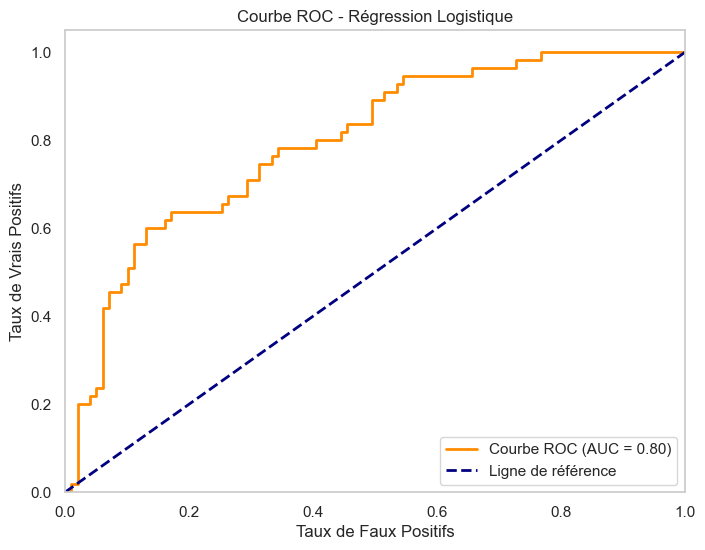

LogisticRegression - Précision sur l'ensemble d'entraînement: 0.7670280274986779 (0.038236417515085615)
AUC-ROC: 0.7961

Rapport de classification:
                precision    recall  f1-score   support

Pas de Diabète       0.80      0.82      0.81        99
       Diabète       0.66      0.64      0.65        55

      accuracy                           0.75       154
     macro avg       0.73      0.73      0.73       154
  weighted avg       0.75      0.75      0.75       154



C:\Users\intel\AppData\Local\Temp\ipykernel_10088\1013657718.py:133: MatplotlibDeprecationWarning: You have mixed positional and keyword arguments, some input may be discarded.  This is deprecated since 3.9 and will become an error in 3.11.
  plt.legend(['Coefficients négatifs', 'Coefficients positifs'],


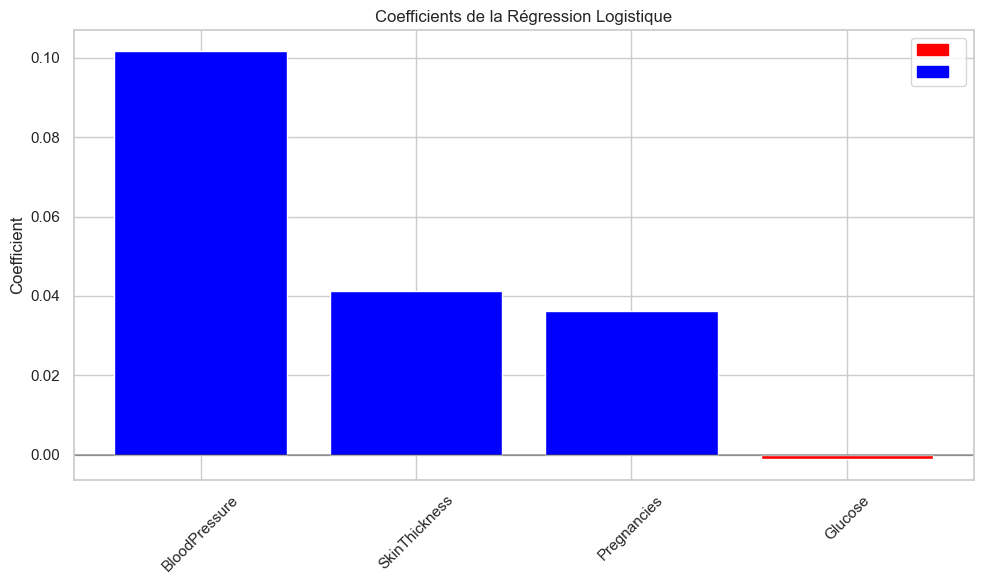

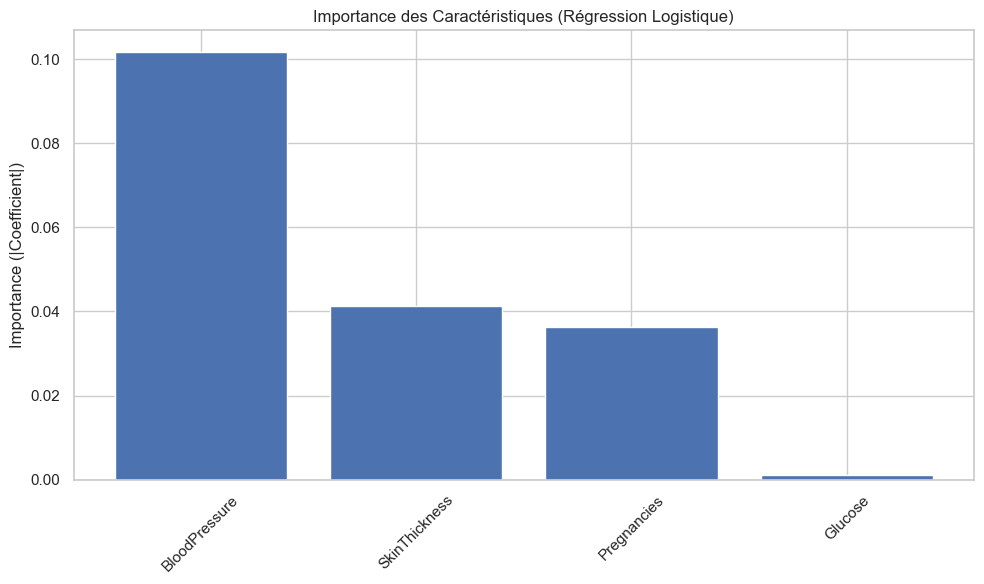

Précision sur l'ensemble de test: 0.7532
Intercept (biais): -9.7586
Coefficients par caractéristique:
  Pregnancies: 0.0362
  Glucose: -0.0011
  BloodPressure: 0.1017
  SkinThickness: 0.0414


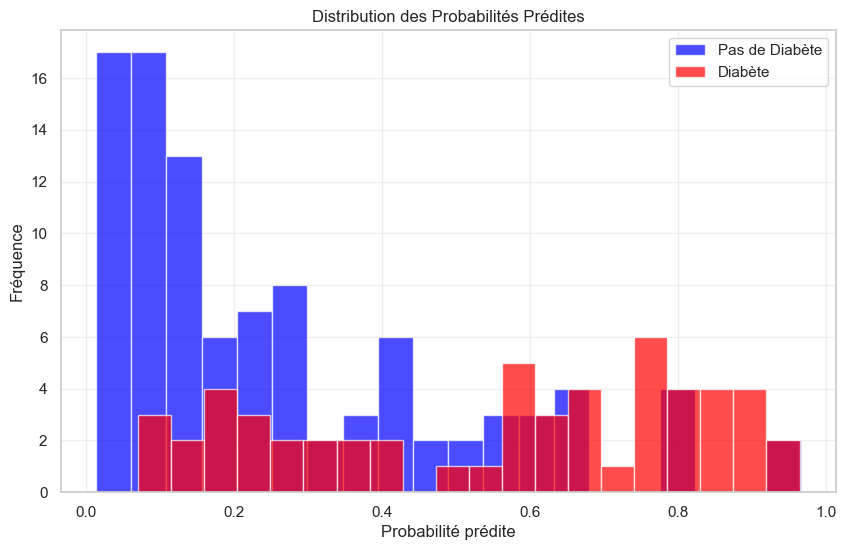

In [23]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import make_scorer, accuracy_score, confusion_matrix, classification_report, roc_curve, auc
from sklearn import model_selection
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import seaborn as sns

# data preparation
X = data.drop('Outcome', axis=1)
Y = data['Outcome']

# function to plot learning curve
def courbe_apprentissage(estimator, title, X, Y, ylim=None, cv=None, n_jobs=None):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, Y, cv=cv, n_jobs=n_jobs, 
        train_sizes=np.linspace(.1, 1.0, 5), random_state=42)
    
    train_scores_mean = np.mean(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    
    plt.figure(figsize=(10, 6))
    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("Nombre d'exemples d'entraînement")
    plt.ylabel("Score")
    plt.grid()
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Score d'entraînement")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Score de validation croisée")
    plt.legend(loc="best")
    return plt

# Function to plot the confusion matrix
def matrice_confusion(cm, classes, title='Matrice de confusion', cmap=plt.cm.Blues):
    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)
    
    fmt = 'd'
    thresh = cm.max() / 2.
    for i, j in np.ndindex(cm.shape):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
    
    plt.ylabel('Vraie étiquette')
    plt.xlabel('Étiquette prédite')
    plt.tight_layout()
    return plt

# Function to plot the ROC curve and calculate AUC
def roc_courbe(y_true, y_proba, title='Courbe ROC'):
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Courbe ROC (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Ligne de référence')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Taux de Faux Positifs')
    plt.ylabel('Taux de Vrais Positifs')
    plt.title(title)
    plt.legend(loc="lower right")
    plt.grid()
    plt.show()
    return roc_auc

# logistic regression function
def Regression_logistique(a, b, c, d):
    model = LogisticRegression(random_state=42, max_iter=1000)
    accuracy_scorer = make_scorer(accuracy_score)
    model.fit(a, b)
    
    kfold = model_selection.KFold(n_splits=10, random_state=7, shuffle=True)
    accuracy = model_selection.cross_val_score(model, a, b, cv=kfold, scoring='accuracy')
    mean = accuracy.mean() 
    stdev = accuracy.std()
    prediction = model.predict(c)
    prediction_proba = model.predict_proba(c)[:, 1]  
    cnf_matrix = confusion_matrix(d, prediction)
    
    class_names = ['Pas de Diabète', 'Diabète']
    
    # learning curve 
    courbe_apprentissage(model, 'Courbe d\'Apprentissage pour LogisticRegression', a, b, (0.60,1.1), 10)
    plt.show()
    
    # confusion matrix
    matrice_confusion(cnf_matrix, classes=class_names, title='Matrice de confusion - Régression Logistique')
    plt.show()
    
    # ROC curve
    roc_auc = roc_courbe(d, prediction_proba, 'Courbe ROC - Régression Logistique')
    
    print('LogisticRegression - Précision sur l\'ensemble d\'entraînement: %s (%s)' % (mean, stdev))
    print(f'AUC-ROC: {roc_auc:.4f}')
    print('\nRapport de classification:')
    print(classification_report(d, prediction, target_names=class_names))
    
    return model

# Logistic Rgression Execution
model = Regression_logistique(X_train, Y_train, X_test, Y_test)

# dataset features names 
feature_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness','Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

# Logistic regression coefficient visualisation 
def plot_coefficients(model, feature_names):
    """
    Visualise les coefficients de la régression logistique
    """
    coefficients = model.coef_[0]
    indices = np.argsort(np.abs(coefficients))[::-1]
    
    plt.figure(figsize=(10, 6))
    colors = ['red' if coef < 0 else 'blue' for coef in coefficients[indices]]
    plt.title("Coefficients de la Régression Logistique")
    bars = plt.bar(range(len(coefficients)), coefficients[indices], color=colors)
    plt.xticks(range(len(coefficients)), [feature_names[i] for i in indices], rotation=45)
    plt.ylabel('Coefficient')
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
    
    # Légende
    plt.legend(['Coefficients négatifs', 'Coefficients positifs'], 
               handles=[plt.Rectangle((0,0),1,1, color='red'), plt.Rectangle((0,0),1,1, color='blue')])
    plt.tight_layout()
    plt.show()

# feature importance based on absolute value of coefficients
def importante_caracteristic_logistic(model, feature_names):
    """
    Affiche l'importance des caractéristiques basée sur la valeur absolue des coefficients
    """
    importances = np.abs(model.coef_[0])
    indices = np.argsort(importances)[::-1]
    
    plt.figure(figsize=(10, 6))
    plt.title("Importance des Caractéristiques (Régression Logistique)")
    plt.bar(range(len(importances)), importances[indices])
    plt.xticks(range(len(importances)), [feature_names[i] for i in indices], rotation=45)
    plt.ylabel('Importance (|Coefficient|)')
    plt.tight_layout()
    plt.show()

# creation and training of the logistic regression model
clf1 = LogisticRegression(random_state=42, max_iter=1000, C=1.0, penalty='l2')
clf1.fit(X_train, Y_train)

# coefficients visualisation
plot_coefficients(clf1, feature_names)

# caracteristics importance visualisation
importante_caracteristic_logistic(clf1, feature_names)

# model evaluation
print(f"Précision sur l'ensemble de test: {clf1.score(X_test, Y_test):.4f}")

# model informations
print(f"Intercept (biais): {clf1.intercept_[0]:.4f}")
print("Coefficients par caractéristique:")
for feature, coef in zip(feature_names, clf1.coef_[0]):
    print(f"  {feature}: {coef:.4f}")

def plot_prediction_probabilities(model, X_test, Y_test):
    """
    Affiche la distribution des probabilités prédites
    """
    probas = model.predict_proba(X_test)[:, 1]
    
    plt.figure(figsize=(10, 6))
    plt.hist(probas[Y_test == 0], bins=20, alpha=0.7, label='Pas de Diabète', color='blue')
    plt.hist(probas[Y_test == 1], bins=20, alpha=0.7, label='Diabète', color='red')
    plt.xlabel('Probabilité prédite')
    plt.ylabel('Fréquence')
    plt.title('Distribution des Probabilités Prédites')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

# Affichage des probabilités prédites
plot_prediction_probabilities(clf1, X_test, Y_test)

# Arbre De Décision

##### In this part, we will train a decision tree classifier to predict diabetes. We'll split the data into training and testing sets, then fit the model to the data. Finally, we'll evaluate its performance using metrics like a learning curve, confusion matrix, and accuracy score, while also visualizing the decision tree structure and the importance of each feature to understand how the model makes its predictions

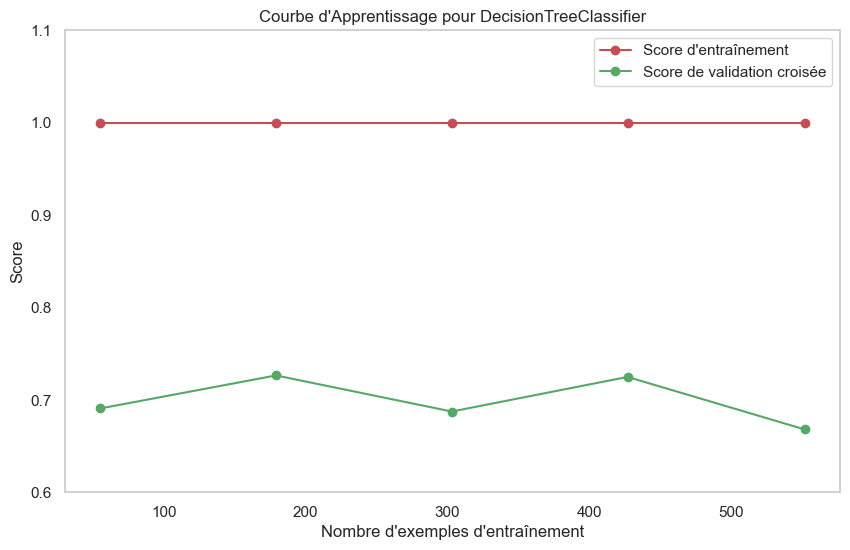

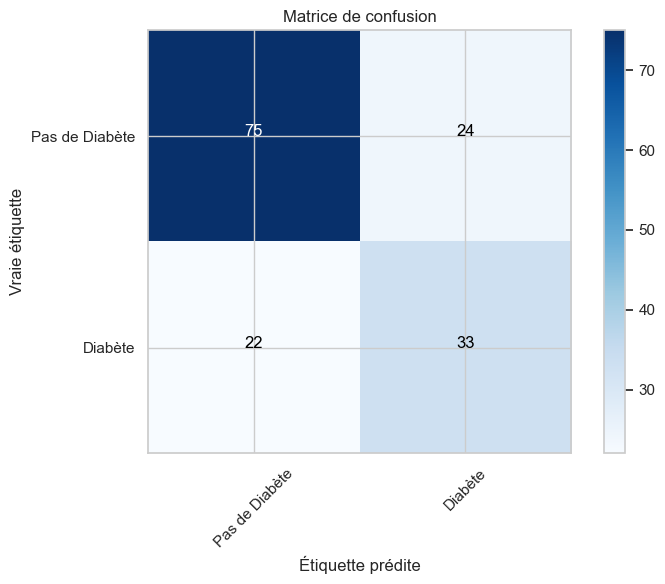

DecisionTreeClassifier - Précision sur l'ensemble d'entraînement: 0.7069539925965099 (0.0556833476014933)


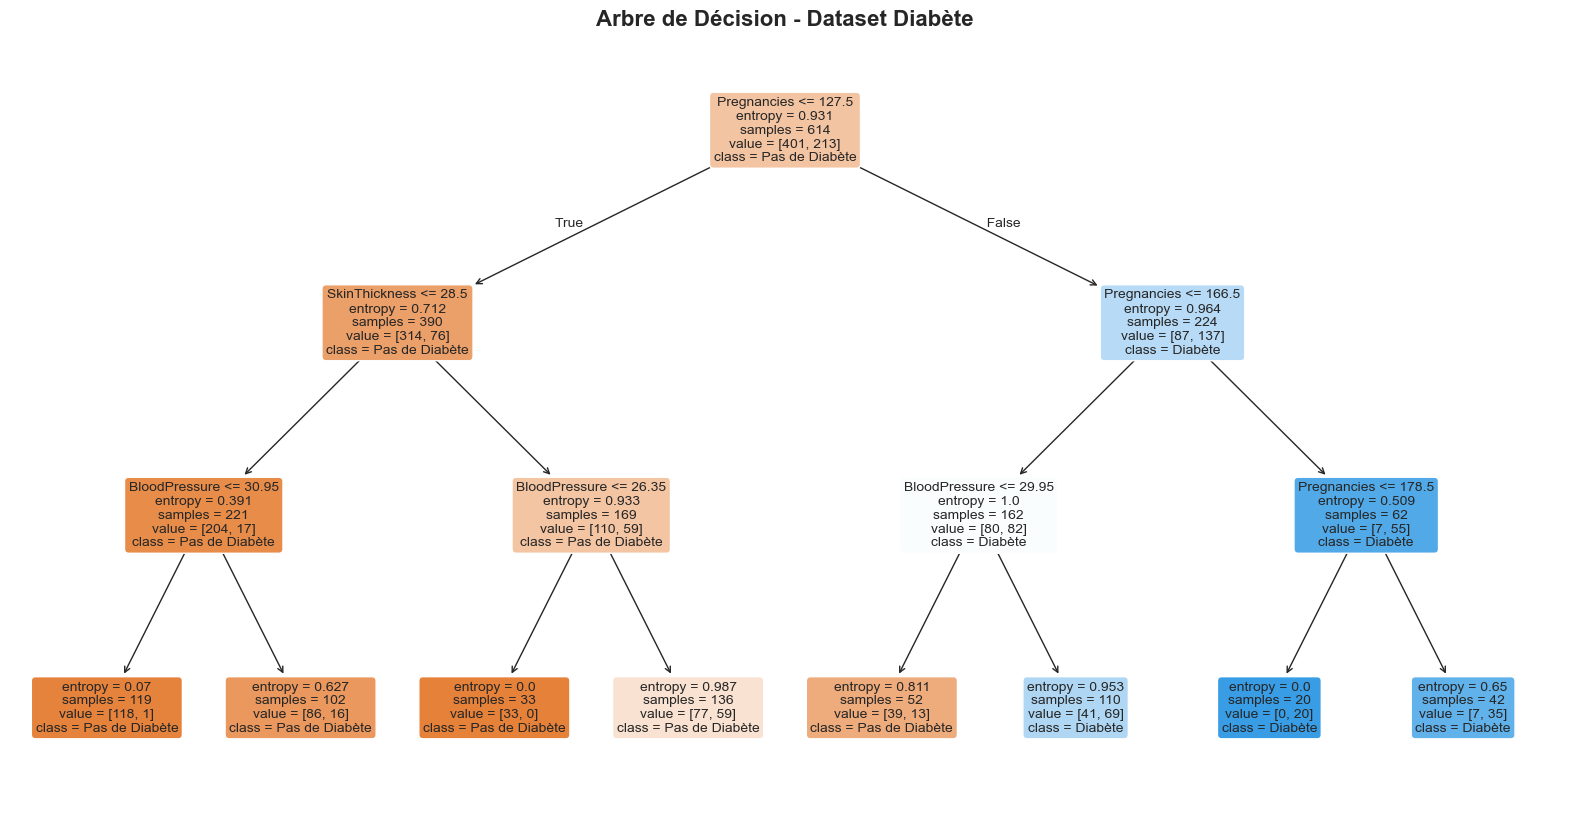

Précision sur l'ensemble de test: 0.7727
Nombre de nœuds dans l'arbre: 15
Profondeur de l'arbre: 3


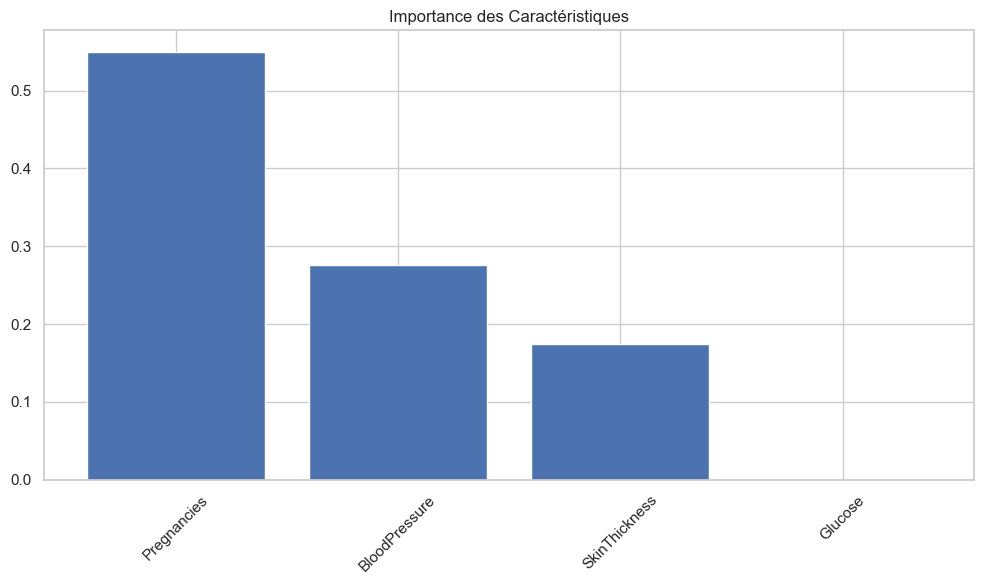

In [24]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import make_scorer, accuracy_score, confusion_matrix
from sklearn import model_selection
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
from sklearn import tree

# Function to plot the learning curve
def courbe_apprentissage(estimator, title, X, y, ylim=None, cv=None, n_jobs=None):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, 
        train_sizes=np.linspace(.1, 1.0, 5), random_state=42)
    
    train_scores_mean = np.mean(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    
    plt.figure(figsize=(10, 6))
    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("Nombre d'exemples d'entraînement")
    plt.ylabel("Score")
    plt.grid()
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Score d'entraînement")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Score de validation croisée")
    plt.legend(loc="best")
    return plt

# Function to plot the confusion matrix
def matrice_confusion(cm, classes, title='Matrice de confusion', cmap=plt.cm.Blues):
    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)
    
    fmt = 'd'
    thresh = cm.max() / 2.
    for i, j in np.ndindex(cm.shape):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
    
    plt.ylabel('Vraie étiquette')
    plt.xlabel('Étiquette prédite')
    plt.tight_layout()
    return plt

# Main function to run the decision tree
def Arbre_decision(a, b, c, d):
    model = DecisionTreeClassifier(criterion='entropy', random_state=42)
    accuracy_scorer = make_scorer(accuracy_score)
    model.fit(a, b)
    
    kfold = model_selection.KFold(n_splits=10, random_state=7, shuffle=True)
    accuracy = model_selection.cross_val_score(model, a, b, cv=kfold, scoring='accuracy')
    mean = accuracy.mean() 
    stdev = accuracy.std()
    prediction = model.predict(c)
    cnf_matrix = confusion_matrix(d, prediction)
    
    class_names = ['Pas de Diabète', 'Diabète']
    
    courbe_apprentissage(model, 'Courbe d\'Apprentissage pour DecisionTreeClassifier', a, b, (0.60,1.1), 10)
    plt.show()
    matrice_confusion(cnf_matrix, classes=class_names, title='Matrice de confusion')
    plt.show()
    print('DecisionTreeClassifier - Précision sur l\'ensemble d\'entraînement: %s (%s)' % (mean, stdev))
    return model

# Execution of the decision tree
model = Arbre_decision(X_train, Y_train, X_test, Y_test)
# Feature names for the diabetes dataset
feature_names1 = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 
                  'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

# Function to visualize the decision tree with matplotlib
def DecisionTree_visualisation(model, feature_names, class_names, max_depth=3):
    """
    Visualise l'arbre de décision en utilisant matplotlib au lieu de graphviz
    """
    plt.figure(figsize=(20, 10))
    tree.plot_tree(model, 
                   feature_names=feature_names,
                   class_names=class_names,
                   filled=True,           # Colors nodes according to the majority class
                   rounded=True,          # Rounds the corners of the nodes
                   fontsize=10,           # Font size
                   max_depth=max_depth)   # Maximum depth to display
    plt.title('Arbre de Décision - Dataset Diabète', fontsize=16, fontweight='bold')
    plt.show()

# Creation and visualization of the optimized decision tree
clf1 = DecisionTreeClassifier(criterion='entropy', random_state=42, max_depth=3, min_samples_leaf=12)
clf1.fit(X_train, Y_train)

# Visualization with matplotlib
DecisionTree_visualisation(clf1, feature_names1, ['Pas de Diabète', 'Diabète'], max_depth=3)

# model evaluation
print(f"Précision sur l'ensemble de test: {clf1.score(X_test, Y_test):.4f}")

# Displaying tree information
print(f"Nombre de nœuds dans l'arbre: {clf1.tree_.node_count}")
print(f"Profondeur de l'arbre: {clf1.tree_.max_depth}")

# Visualizing feature importance
def importante_caracteristiques(model, feature_names):
    """
    Affiche l'importance des caractéristiques
    """
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1]
    
    plt.figure(figsize=(10, 6))
    plt.title("Importance des Caractéristiques")
    plt.bar(range(len(importances)), importances[indices])
    plt.xticks(range(len(importances)), [feature_names[i] for i in indices], rotation=45)
    plt.tight_layout()
    plt.show()

# Displaying feature importance
importante_caracteristiques(clf1, feature_names1)
